# Dominican Film Industry — CIPAC Resolutions EDA

**Author:** Jorge Doiany Peguero Almonte  
**GitHub:** [jorgedoiany](https://github.com/jorgedoiany)  
**Dataset:** Supabase — `cipac_resolutions`  
**Period:** 2012–2026  
**Last updated:** August 2026  

---

## Overview

This notebook presents an exploratory data analysis (EDA) of the CIPAC investment and expense validation resolutions issued by the **Dominican Film Commission** ([DGCINE](https://dgcine.gob.do)) between 2012 and 2026 under Law 108-10.

The goal is to uncover patterns and trends in film investment, tax credits, production budgets, and key industry players (investors and production companies).

This analysis serves as the foundation for the **Dominican Film Industry Executive Dashboard**, built with Python and Streamlit.

---

## Key Concepts

**Law 108-10** — Dominican Republic's Film Promotion Law, which establishes tax incentives for local and foreign film productions.

**DGCINE** — Dirección General de Cine (Dominican Film Commission). The government body responsible for regulating and promoting the Dominican film industry.

**CIPAC** — Consejo Intersectorial para la Promoción de la Actividad Cinematográfica. The council that reviews and approves investment and expense validation requests.

**Art. 34 — Investment Validation (Validación de Inversión)**  
Applies to Dominican productions. Local investors (companies or individuals) who fund a Dominican film can receive a tax credit equivalent to 100% of their validated investment, applicable against their income tax (ISR). The production must hold a CPND certificate.

**Art. 39 — Expense Validation (Validación de Gastos)**  
Applies to foreign productions filming in the Dominican Republic. Foreign producers can receive a transferable tax credit equivalent to 25% of their validated expenses in the country.

**CIPAC Resolution** — The official document issued by CIPAC that validates an investment (Art. 34) or expense (Art. 39) and authorizes the corresponding tax credit. Each resolution corresponds to one investor or production company per project. A single film can have multiple resolutions if it has multiple investors.

**CPND** — Certificado de Nacionalidad Dominicana. Certificate issued to Dominican productions before filming begins, required for Art. 34 incentives.

**PUR** — Permiso Único de Rodaje. Filming permit required for all productions (both Dominican and foreign) before filming begins.

**Tax Credit** — A reduction in taxes owed, not a cash payment. Under Art. 34, the credit equals 100% of the validated investment. Under Art. 39, it equals 25% of validated expenses in the DR.

---

## Dataset Variables

| Variable | Description |
|---|---|
| `year` | Year the resolution was issued |
| `incentive_article` | Incentive type: `art_34` (Dominican) or `art_39` (Foreign) |
| `resolution_type` | Outcome: `approved` or `rejected` |
| `investor_name` | Name of the local investor (Art. 34 only) |
| `investor_rnc` | Tax ID (RNC) of the investor (Art. 34 only) |
| `local_company` | Dominican production company representing the project |
| `producer_rnc` | Tax ID (RNC) of the production company |
| `film_title` | Title of the cinematographic work |
| `pur_number` | Filming permit number (Permiso Único de Rodaje) |
| `cpnd_number` | Dominican nationality certificate number (Art. 34 only) |
| `request_date` | Date the validation request was submitted |
| `resolution_date` | Date the resolution was issued |
| `validated_expenses_dop` | Total validated investment or expenses in DOP |
| `tax_credit_dop` | Tax credit authorized in DOP |
| `tax_credit_pct` | Tax credit percentage (100% for Art. 34, 25% for Art. 39) |
| `total_budget_approved` | Total production budget approved in the CPND/PUR |
| `total_budget_executed` | Total production budget actually executed |

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Missing Values Analysis](#3-missing-values-analysis)
4. [Resolutions by Year](#4-resolutions-by-year)
5. [Art. 34 vs Art. 39](#5-art-34-vs-art-39)
6. [Top Art. 34 Investors](#6-top-art-34-investors)
7. [Top Art. 34 Production Companies](#7-top-art-34-production-companies)
8. [Top Art. 39 Production Companies](#8-top-art-39-production-companies)
9. [Validated Amounts & Tax Credits](#9-validated-amounts--tax-credits)
10. [Correlation Analysis](#10-correlation-analysis)
11. [Budget Analysis (Approved vs Executed)](#11-budget-analysis-approved-vs-executed)
12. [Key Findings & Conclusions](#12-key-findings--conclusions)

## 1. Setup & Data Loading

In [1]:
# --- Standard libraries ---
import pandas as pd
import numpy as np
import os
import sys

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --- Database ---
from sqlalchemy import create_engine
from dotenv import load_dotenv

# --- Display settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Plot style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
load_dotenv()

engine = create_engine(os.getenv('SUPABASE_DB_URL') or '')

df = pd.read_sql("""
    SELECT
        resolution_number,
        year,
        incentive_article,
        resolution_type,
        investor_name,
        investor_rnc,
        producer_rnc,
        film_title,
        local_company,
        pur_number,
        cpnd_number,
        request_date,
        resolution_date,
        validated_expenses_dop,
        tax_credit_dop,
        tax_credit_pct,
        total_budget_approved,
        total_budget_executed
    FROM cipac_resolutions
    ORDER BY year, resolution_number
""", engine)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset loaded: 2532 rows x 18 columns


,resolution_number,year,incentive_article,resolution_type,investor_name,investor_rnc,producer_rnc,film_title,local_company,pur_number,cpnd_number,request_date,resolution_date,validated_expenses_dop,tax_credit_dop,tax_credit_pct,total_budget_approved,total_budget_executed
0,CIPAC-2012-001,2012,art_39,approved,NaN,NaN,1-30-83426-1,THE TRUTH,"FILM001, INC",002,NaN,2012-02-29,2012-03-29,46168271.82,11542067.96,25.00,38432098.00,46168271.82
1,CIPAC-2012-002,2012,art_34,approved,"VIDEO UNIVERSAL, S.R.L.",1-22-00857-8,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,990000.00,990000.00,100.00,14240247.18,14240247.00
2,CIPAC-2012-003,2012,art_34,approved,"RSD REMANUFACTURE SOLUTIONS DOMINICANA, S.R.L.",1-30-23890-1,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,990000.00,990000.00,100.00,14240247.18,14240247.00
3,CIPAC-2012-004,2012,art_34,approved,SERVICIOS INFORMATIVOS NACIONALES NOTICIAS SIN...,1-30-17966-2,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,1073142.97,1073142.97,100.00,14240247.18,14240247.00
4,CIPAC-2012-005,2012,art_34,approved,"UNITED BRANDS, S.A.",1-24-01933-8,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,8257892.64,8257892.64,100.00,14240247.18,14240247.00
5,CIPAC-2012-010,2012,art_34,approved,"ALTICE DOMINICANA, S.A.",1-01-61878-7,1-30-84607-3,LOTOMAN 2.0,"DRAGON FILMS, S.R.L.",010,002,2012-07-09,2012-07-19,20000000.00,20000000.00,100.00,46885882.50,51392492.71
6,CIPAC-2012-011,2012,art_34,approved,"AES ANDRES DR, S.A.",1-01-83722-5,1-30-84607-3,LOTOMAN 2.0,"DRAGON FILMS, S.R.L.",010,002,2012-07-09,2012-07-19,25000000.00,25000000.00,100.00,46885882.50,51392492.71
7,CIPAC-2012-012,2012,art_34,approved,"BANCO MÚLTIPLE BDI, S.A.",1-01-04029-7,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",007,004,2012-07-09,2012-07-19,3504473.00,3504473.00,100.00,29736672.00,10284540.00
8,CIPAC-2012-013,2012,art_34,approved,"CENTROS DEL CARIBE, S.A.S.",1-01-70451-9,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",007,004,2012-07-09,2012-07-19,3504473.00,3504473.00,100.00,29736672.00,10284540.00
9,CIPAC-2012-014,2012,art_34,approved,"ANTONIO CHAHAIN M, S.A.",1-01-08822-2,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",007,004,2012-07-09,2012-07-19,802405.51,802405.51,100.00,29736672.00,10284540.00


## 2. Dataset Overview

A quick look at the structure, data types, and basic statistics of the dataset.

In [3]:
print(f"Shape: {df.shape[0]} resolutions × {df.shape[1]} columns")
print(f"\nColumns:\n")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Shape: 2532 resolutions × 18 columns

Columns:

  - resolution_number (str)
  - year (str)
  - incentive_article (str)
  - resolution_type (str)
  - investor_name (str)
  - investor_rnc (str)
  - producer_rnc (str)
  - film_title (str)
  - local_company (str)
  - pur_number (str)
  - cpnd_number (str)
  - request_date (str)
  - resolution_date (str)
  - validated_expenses_dop (float64)
  - tax_credit_dop (float64)
  - tax_credit_pct (float64)
  - total_budget_approved (float64)
  - total_budget_executed (float64)


In [4]:
df.describe(include='all')

,resolution_number,year,incentive_article,resolution_type,investor_name,investor_rnc,producer_rnc,film_title,local_company,pur_number,cpnd_number,request_date,resolution_date,validated_expenses_dop,tax_credit_dop,tax_credit_pct,total_budget_approved,total_budget_executed
count,2532,2532,2532,2532,2448,2448,2532,2532,2532,2531,2446,2528,2532,2532.00,2528.00,2532.00,2531.00,2529.00
unique,2532,15,2,2,494,492,367,665,373,613,537,676,195,NaN,NaN,NaN,NaN,NaN
top,CIPAC-2012-001,2023,art_34,approved,"CERVECERÍA NACIONAL DOMINICANA, S.A.",1-01-01063-2,1-30-99100-6,EL PODER DE LAS TINIEBLAS,"PILÓN PRODUCTIONS, S.R.L.",152,124,2023-01-17,2023-03-02,NaN,NaN,NaN,NaN,NaN
freq,1,331,2448,2528,86,87,59,29,59,29,29,38,105,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20718154.26,12131255.99,97.51,78450948.77,55460843.33
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132195109.25,35609017.06,13.43,239919861.85,169307699.77
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,25.00,3160270.00,16.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000000.00,2000000.00,100.00,39418654.00,22385000.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000000.00,5000000.00,100.00,59919855.00,39989577.03
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11000000.00,10373478.50,100.00,73957343.69,61100000.00


## 3. Missing Values Analysis

Understanding data completeness is critical before building any visualization or model. Columns with high missing rates may need to be excluded or imputed.

In [5]:
# Missing values summary
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]
print(f"{len(missing)} columns have missing values:\n")
print(missing.to_string())

8 columns have missing values:

                       missing_count  missing_pct
cpnd_number                       86         3.40
investor_rnc                      84         3.32
investor_name                     84         3.32
request_date                       4         0.16
tax_credit_dop                     4         0.16
total_budget_executed              3         0.12
pur_number                         1         0.04
total_budget_approved              1         0.04


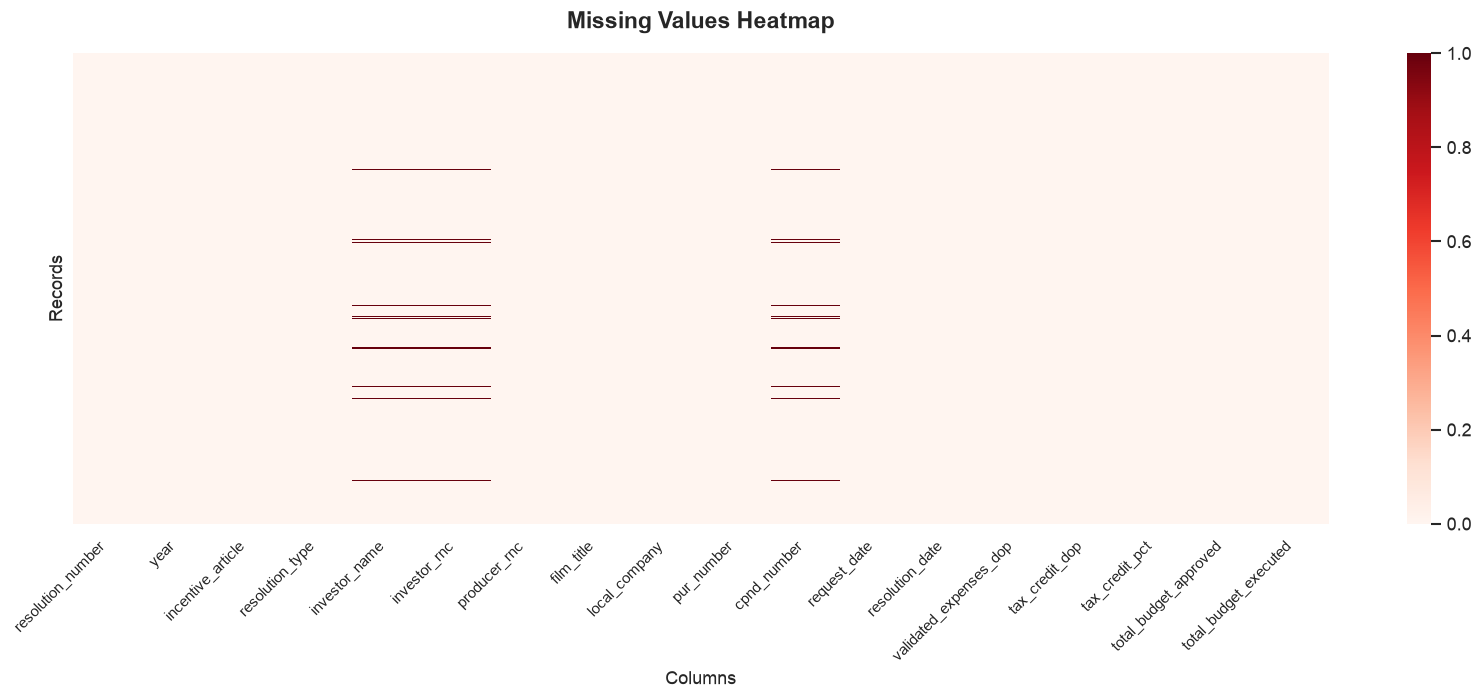

In [6]:
# Heatmap of missing values
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='Reds',
    yticklabels=False,
    ax=ax
)

ax.set_title('Missing Values Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Columns', fontsize=11)
ax.set_ylabel('Records', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Resolutions by Year

Analyzing how CIPAC resolution volume has evolved year over year from 2012 to 2026.

In [7]:
# Resolutions per year by resolution type
res_by_year_type = df.groupby(['year', 'resolution_type']).size().reset_index(name='count')

fig = px.bar(
    res_by_year_type,
    x='year',
    y='count',
    color='resolution_type',
    title='CIPAC Resolutions by Year (2012–2026)',
    labels={'year': 'Year', 'count': 'Number of Resolutions', 'resolution_type': 'Resolution Type'},
    barmode='stack',
    color_discrete_map={'approved': '#1f77b4', 'rejected': '#d62728'}
)
fig.update_layout(showlegend=True)
fig.show()

res_per_year = df['year'].value_counts().sort_index()
print(f"\nPeak year:   {res_per_year.idxmax()} ({res_per_year.max()} resolutions)")
print(f"Lowest year: {res_per_year.idxmin()} ({res_per_year.min()} resolutions)")
print(f"Average:     {res_per_year.mean():.0f} resolutions/year")

print(f"\nTotal approved:  {len(df[df['resolution_type'] == 'approved'])}")
print(f"Total rejected:  {len(df[df['resolution_type'] == 'rejected'])}")


Peak year:   2023 (331 resolutions)
Lowest year: 2012 (14 resolutions)
Average:     169 resolutions/year

Total approved:  2528
Total rejected:  4


## 5. Art. 34 vs Art. 39

Analyzing the distribution between Dominican productions (Art. 34) and foreign productions (Art. 39) under Law 108-10.

In [8]:
# Distribution by incentive article
article_counts = df['incentive_article'].value_counts()
article_labels = {'art_34': 'Art. 34 (Dominican)', 'art_39': 'Art. 39 (Foreign)'}
article_counts.index = article_counts.index.map(article_labels)

fig = px.pie(
    values=article_counts.values,
    names=article_counts.index,
    title='Resolutions by Incentive Article',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

In [9]:
# Resolutions by year and incentive article
df['article_label'] = df['incentive_article'].map(article_labels)

res_by_year_article = df.groupby(['year', 'article_label']).size().reset_index(name='count')

fig = px.bar(
    res_by_year_article,
    x='year',
    y='count',
    color='article_label',
    title='Resolutions by Year and Incentive Article',
    labels={'year': 'Year', 'count': 'Number of Resolutions', 'article_label': 'Article'},
    barmode='stack'
)
fig.show()

In [10]:
# Distribution by incentive article and resolution type
art_type = df.groupby(['incentive_article', 'resolution_type']).size().reset_index(name='count')
art_type['article_label'] = art_type['incentive_article'].map({
    'art_34': 'Art. 34 (Dominican)',
    'art_39': 'Art. 39 (Foreign)'
})

fig = px.bar(
    art_type,
    x='article_label',
    y='count',
    color='resolution_type',
    title='Resolutions by Incentive Article and Resolution Type',
    labels={'article_label': 'Incentive Article', 'count': 'Number of Resolutions', 'resolution_type': 'Resolution Type'},
    barmode='group',
    color_discrete_map={'approved': '#1f77b4', 'rejected': '#d62728'}
)
fig.show()

print(f"\nArt. 34 — Approved: {len(df[(df['incentive_article'] == 'art_34') & (df['resolution_type'] == 'approved')])} | Rejected: {len(df[(df['incentive_article'] == 'art_34') & (df['resolution_type'] == 'rejected')])}")
print(f"Art. 39 — Approved: {len(df[(df['incentive_article'] == 'art_39') & (df['resolution_type'] == 'approved')])} | Rejected: {len(df[(df['incentive_article'] == 'art_39') & (df['resolution_type'] == 'rejected')])}")
print(f"\nTotal  — Approved: {len(df[df['resolution_type'] == 'approved'])} | Rejected: {len(df[df['resolution_type'] == 'rejected'])}")


Art. 34 — Approved: 2444 | Rejected: 4
Art. 39 — Approved: 84 | Rejected: 0

Total  — Approved: 2528 | Rejected: 4


### For the following sections, only **approved** resolutions are included since rejected resolutions do not have validated amounts or tax credits.

In [11]:
# Filter approved resolutions only for financial analysis
df_approved = df[df['resolution_type'] == 'approved']
df_34 = df_approved[df_approved['incentive_article'] == 'art_34']
df_39 = df_approved[df_approved['incentive_article'] == 'art_39']

print(f"Approved resolutions: {len(df_approved)}")
print(f"  Art. 34: {len(df_34)}")
print(f"  Art. 39: {len(df_39)}")

Approved resolutions: 2528
  Art. 34: 2444
  Art. 39: 84


## 6. Top Art. 34 Investors

Identifying the most active local investors in Dominican film productions under Art. 34 of Law 108-10. Only Art. 34 resolutions are included, as Art. 39 applies to foreign productions where the applicant is the **foreign producer, not a local investor**.

In [12]:
# Top 15 investors by number of resolutions (Art. 34 only)
df_34 = df[df['incentive_article'] == 'art_34']
top_investors = df_34['investor_name'].value_counts().head(15)

fig = px.bar(
    x=top_investors.values,
    y=top_investors.index,
    orientation='h',
    title='Top 15 Art. 34 Investors by Number of Resolutions',
    labels={'x': 'Number of Resolutions', 'y': 'Investor', 'color': 'Number of Resolutions'},
    color=top_investors.values,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [13]:
# Top 15 investors by total tax credit (Art. 34 only)
top_investors_credit = (
    df_34.groupby('investor_name')['tax_credit_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_investors_credit.to_numpy(dtype='float64') / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_investors_credit.index,
    orientation='h',
    title='Top 15 Art. 34 Investors by Total Tax Credit (RD$ millions)',
    labels={'x': 'Total Tax Credit (RD$ millions)', 'y': 'Investor', 'color': 'Total Tax Credit (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Greens'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

## 7. Top Art. 34 Production Companies

Identifying the most active Dominican production companies under Art. 34 of Law 108-10, based on the number of resolutions and total validated investment amounts received from local investors.

In [14]:
# Top 15 Art. 34 production companies by number of resolutions
top_companies_34 = df_34['local_company'].value_counts().head(15)

fig = px.bar(
    x=top_companies_34.values,
    y=top_companies_34.index,
    orientation='h',
    title='Top 15 Art. 34 Production Companies by Number of Resolutions',
    labels={'x': 'Number of Resolutions', 'y': 'Production Company', 'color': 'Number of Resolutions'},
    color=top_companies_34.values,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [15]:
# Top 15 Art. 34 production companies by total validated amount
top_companies_34_amount = (
    df_34.groupby('local_company')['validated_expenses_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_companies_34_amount.to_numpy(dtype='float64') / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_companies_34_amount.index,
    orientation='h',
    title='Top 15 Art. 34 Production Companies by Total Validated Amount (RD$ millions)',
    labels={'x': 'Total Validated Amount (RD$ millions)', 'y': 'Production Company', 'color': 'Total Validated Amount (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Purples'
)
fig.update_layout(
    title='Top 15 Art. 34 Production Companies<br>by Total Validated Amount (RD$ millions)',
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

## 8. Top Art. 39 Production Companies

Identifying the most active local production companies representing foreign productions and their validated expenses in the Dominican Republic under Art. 39 of Law 108-10.

In [16]:
# Top 15 foreign productions by number of resolutions (Art. 39 only)
df_39 = df[df['incentive_article'] == 'art_39']
top_foreign = df_39['local_company'].value_counts().head(15)

fig = px.bar(
    x=top_foreign.values,
    y=top_foreign.index,
    orientation='h',
    title='Top 15 Art. 39 Production Companies by Number of Resolutions',
    labels={'x': 'Number of Resolutions', 'y': 'Production Company', 'color': 'Number of Resolutions'},
    color=top_foreign.values,
    color_continuous_scale='Oranges'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [17]:
# Top 15 foreign productions by total validated expenses (Art. 39 only)
top_foreign_expenses = (
    df_39.groupby('local_company')['validated_expenses_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_foreign_expenses.to_numpy(dtype='float64') / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_foreign_expenses.index,
    orientation='h',
    title='Top 15 Art. 39 Production Companies<br>by Total Validated Expenses (RD$ millions)',
    labels={'x': 'Total Validated Expenses (RD$ millions)', 'y': 'Production Company', 'color': 'Total Validated Expenses (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Oranges'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

## 9. Validated Amounts & Tax Credits

Analyzing the total validated investment amounts and tax credits issued under Law 108-10, broken down by incentive article (Art. 34 and Art. 39).

In [18]:
# Total validated amount and tax credit by year (all articles combined)
yearly_total = df_approved.groupby('year').agg(
    total_validated=('validated_expenses_dop', 'sum'),
    total_credit=('tax_credit_dop', 'sum')
).reset_index()

yearly_total['total_validated_m'] = yearly_total['total_validated'] / 1_000_000
yearly_total['total_credit_m'] = yearly_total['total_credit'] / 1_000_000

fig = go.Figure()

fig.add_trace(go.Bar(
    x=yearly_total['year'],
    y=yearly_total['total_validated_m'],
    name='Validated Amount',
    marker_color='#1f77b4'
))

fig.add_trace(go.Bar(
    x=yearly_total['year'],
    y=yearly_total['total_credit_m'],
    name='Tax Credit',
    marker_color='#2ca02c'
))

fig.update_layout(
    title='Total Validated Amount vs Tax Credit by Year (RD$ millions)',
    xaxis_title='Year',
    yaxis_title='RD$ millions',
    barmode='group',
    yaxis=dict(tickformat=',.0f')
)
fig.show()

In [19]:
# By incentive article
yearly = df_approved.groupby(['year', 'incentive_article']).agg(
    total_validated=('validated_expenses_dop', 'sum'),
    total_credit=('tax_credit_dop', 'sum')
).reset_index()

yearly['total_validated_m'] = yearly['total_validated'] / 1_000_000
yearly['total_credit_m'] = yearly['total_credit'] / 1_000_000
yearly['article_label'] = yearly['incentive_article'].map({
    'art_34': 'Art. 34',
    'art_39': 'Art. 39'
})

fig = px.bar(
    yearly,
    x='year',
    y='total_validated_m',
    color='article_label',
    title='Total Validated Amount by Year and Incentive Article (RD$ millions)',
    labels={'year': 'Year', 'total_validated_m': 'Total Validated Amount (RD$ millions)', 'article_label': 'Article'},
    barmode='group',
    color_discrete_map={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'}
)
fig.update_layout(yaxis=dict(tickformat=',.0f'))
fig.show()

fig = px.bar(
    yearly,
    x='year',
    y='total_credit_m',
    color='article_label',
    title='Total Tax Credit by Year and Incentive Article (RD$ millions)',
    labels={'year': 'Year', 'total_credit_m': 'Total Tax Credit (RD$ millions)', 'article_label': 'Article'},
    barmode='group',
    color_discrete_map={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'}
)
fig.update_layout(yaxis=dict(tickformat=',.0f'))
fig.show()

In [20]:
# Average tax credit per resolution by year and incentive article
avg_credit = df_approved.groupby(['year', 'incentive_article'])['tax_credit_dop'].mean().reset_index()
avg_credit['tax_credit_m'] = avg_credit['tax_credit_dop'] / 1_000_000
avg_credit['article_label'] = avg_credit['incentive_article'].map({
    'art_34': 'Art. 34',
    'art_39': 'Art. 39'
})

fig = px.line(
    avg_credit,
    x='year',
    y='tax_credit_m',
    color='article_label',
    title='Average Tax Credit per Resolution by Year (RD$ millions)',
    labels={'year': 'Year', 'tax_credit_m': 'Average Tax Credit (RD$ millions)', 'article_label': 'Article'},
    markers=True,
    color_discrete_map={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'}
)
fig.update_layout(yaxis=dict(tickformat=',.0f'))
fig.show()

## 10. Correlation Analysis

Exploring relationships between the key numerical variables in the dataset.

In [21]:
# Correlation matrix
numeric_cols = ['validated_expenses_dop', 'tax_credit_dop', 'tax_credit_pct', 
                'total_budget_approved', 'total_budget_executed']

corr = df_approved[numeric_cols].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Correlation Matrix — Numerical Variables'
)
fig.update_layout(
    width=600,
    height=500,
    coloraxis_colorbar=dict(title='Correlation')
)
fig.show()

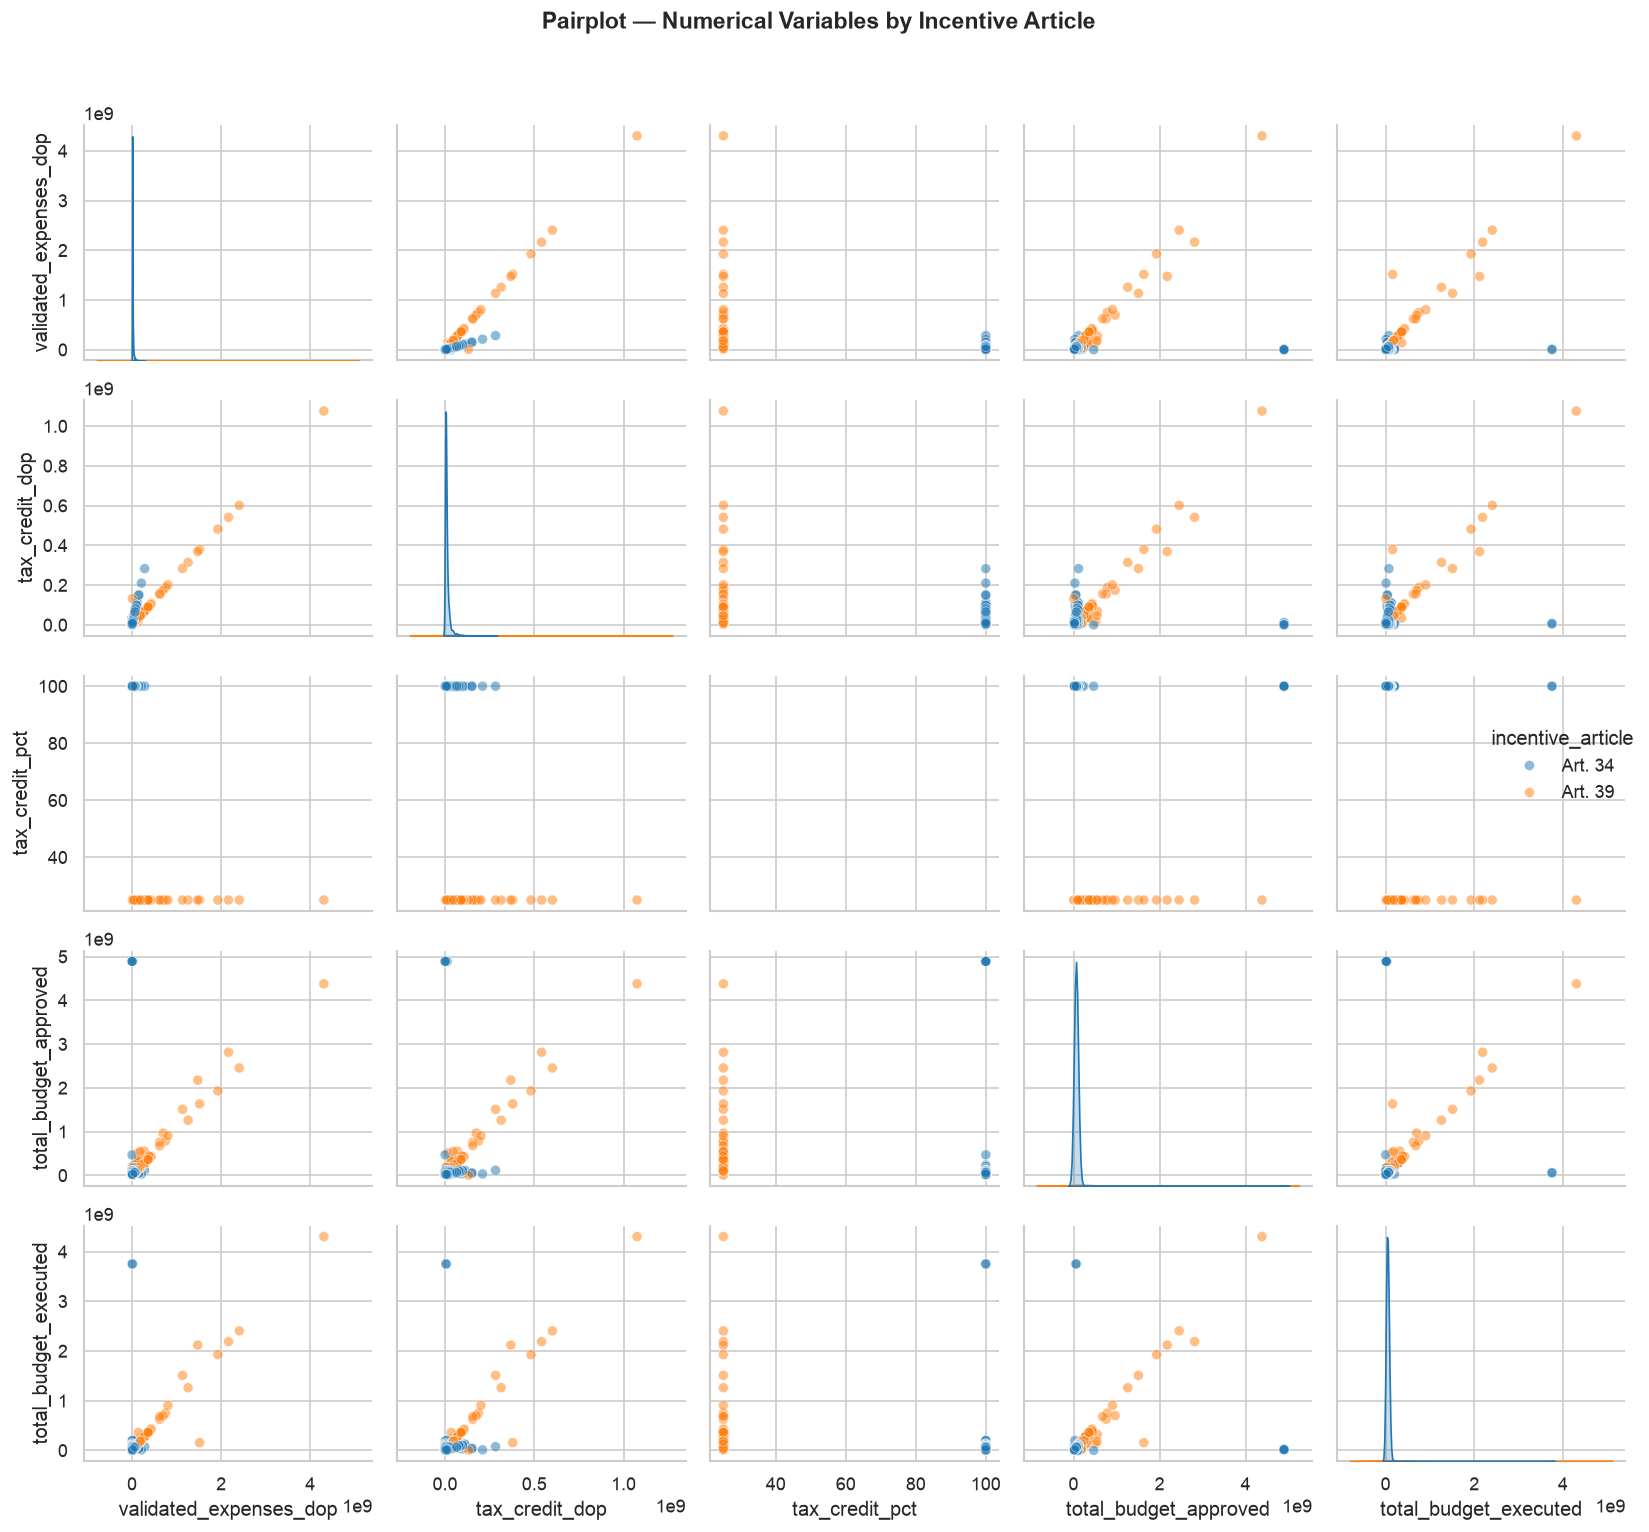

In [22]:
# Pairplot
pairplot_df = df_approved[numeric_cols + ['incentive_article']].dropna()
pairplot_df['incentive_article'] = pairplot_df['incentive_article'].map({
    'art_34': 'Art. 34',
    'art_39': 'Art. 39'
})

g = sns.pairplot(
    pairplot_df,
    hue='incentive_article',
    hue_order=['Art. 34', 'Art. 39'],
    palette={'Art. 34': '#1f77b4', 'Art. 39': '#ff7f0e'},
    plot_kws={'alpha': 0.5},
    diag_kind='kde'
)

g.figure.suptitle('Pairplot — Numerical Variables by Incentive Article',
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Budget Analysis (Approved vs Executed)

Comparing the approved production budgets against the actual executed budgets across years.

In [23]:
# Average approved vs executed budget by year
budget_year = df_approved.groupby('year').agg(
    avg_approved=('total_budget_approved', 'mean'),
    avg_executed=('total_budget_executed', 'mean')
).reset_index()

budget_year['avg_approved_m'] = budget_year['avg_approved'] / 1_000_000
budget_year['avg_executed_m'] = budget_year['avg_executed'] / 1_000_000

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=budget_year['year'],
    y=budget_year['avg_approved_m'],
    mode='lines+markers',
    name='Avg Approved Budget',
    line=dict(color='#1f77b4')
))

fig.add_trace(go.Scatter(
    x=budget_year['year'],
    y=budget_year['avg_executed_m'],
    mode='lines+markers',
    name='Avg Executed Budget',
    line=dict(color='#ff7f0e')
))

fig.update_layout(
    title='Average Approved vs Executed Budget by Year (RD$ millions)',
    xaxis_title='Year',
    yaxis_title='RD$ millions',
    yaxis=dict(tickformat=',.0f')
)
fig.show()

In [24]:
# Budget execution rate by year (executed / approved)
budget_year['execution_rate'] = (
    budget_year['avg_executed'] / budget_year['avg_approved'] * 100
).round(1)

fig = px.bar(
    budget_year,
    x='year',
    y='execution_rate',
    title='Average Budget Execution Rate by Year (%)',
    labels={'year': 'Year', 'execution_rate': 'Execution Rate (%)'},
    color='execution_rate',
    color_continuous_scale='RdYlGn'
)
fig.update_layout(
    yaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(title='%')
)
fig.add_hline(y=100, line_dash='dash', line_color='gray', annotation_text='100%')
fig.show()

## 12. Key Findings & Conclusions